In [1]:
#Monthly Job Postings for Top Data Jobs in the US
import ast
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt

dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

<Axes: ylabel='Frequency'>

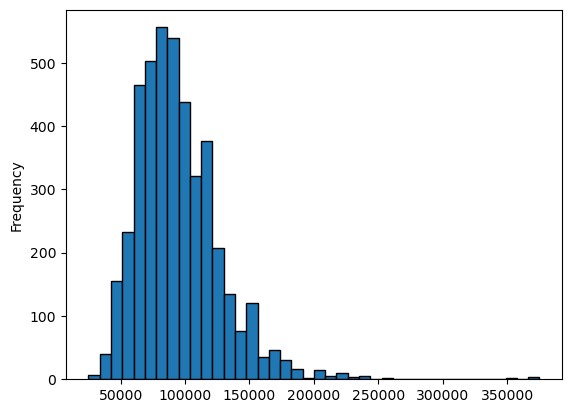

In [ ]:
df_US_DA = df[(df['job_title_short'] == 'Data Analyst') & (df['job_country'] == 'United States')].copy()
df_US_DA = df_US_DA.dropna(subset='salary_year_avg')

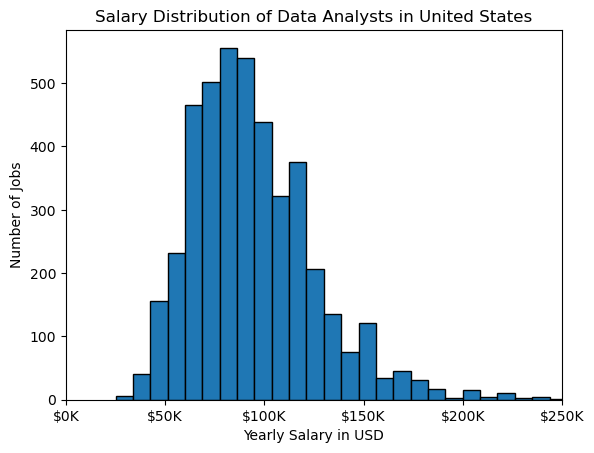

In [12]:
df_US_DA['salary_year_avg'].plot(kind='hist', bins=40, edgecolor='black')
plt.title('Salary Distribution of Data Analysts in United States')
plt.ylabel('Number of Jobs')
plt.xlabel('Yearly Salary in USD')
plt.xlim(0,250000)
ax = plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x,pos: f'${int(x/1000)}K'))